# Memory Experiment — XZZX Surface Code

Rotated XZZX surface code ([Bonilla-Ataides et al.](https://doi.org/10.1038/s41467-021-22274-1))

In [1]:
import sys
from pathlib import Path
import numpy as np

ROOT = Path("../..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lightstim.ir.qec_system import QECSystem
from lightstim.protocols.memory import MemoryExperiment
from lightstim.qec_code.surface_code.xzzx import (
    XZZXSurfaceCode, XZZXSurfaceCodeExtractionBlock, xzzx_memory_basis)

In [2]:
from lightstim.noise.config import NoiseConfig

p = 1e-3
noise_params = NoiseConfig(p_idle=p, p_1q=p, p_2q=p, p_meas=p, p_reset=p)

## 1. Build the memory circuit

In [3]:
d = 3
code = XZZXSurfaceCode(distance=d)
system = QECSystem()
system.add_patch(code, name="xzzx_sc")

basis_map = xzzx_memory_basis(system, "Z")  # generate AFTER add_patch (global indices)

exp = MemoryExperiment(
    qec_system=system,
    extraction_block_class=XZZXSurfaceCodeExtractionBlock,
    rounds=d,
    noise_params=noise_params,
    noise_model="circuit_level",
    basis="Z",
    data_basis_map=basis_map,
)
circuit_xzzx = exp.build()
print(f"Qubits: {circuit_xzzx.num_qubits}  Detectors: {circuit_xzzx.num_detectors}  "
      f"Observables: {circuit_xzzx.num_observables}")

err = circuit_xzzx.shortest_graphlike_error()
print(f"Shortest graphlike error: {len(err)} (expected {d})")
assert len(err) == d

Qubits: 17  Detectors: 24  Observables: 1
Shortest graphlike error: 3 (expected 3)


## 2. The checkerboard

This plot shows the checkerboard pattern of X/Z initialization and readout bases for the data qubits in the XZZX memory experiment.

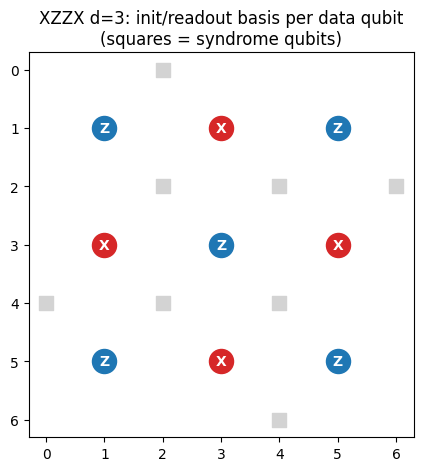

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))
for coord in system.data_coords:
    q = system.index_map[coord]
    b = basis_map[q]
    ax.scatter(*coord, c="tab:blue" if b == "Z" else "tab:red", s=300, zorder=2)
    ax.annotate(b, coord, ha="center", va="center", color="white",
                fontsize=10, fontweight="bold", zorder=3)
for q in system.syndrome_indices:
    ax.scatter(*system.qubit_coords[q], c="lightgray", s=100, marker="s", zorder=1)
ax.set_title(f"XZZX d={d}: init/readout basis per data qubit\n(squares = syndrome qubits)")
ax.set_aspect("equal")
ax.invert_yaxis()
plt.show()

## 3. Detector slice

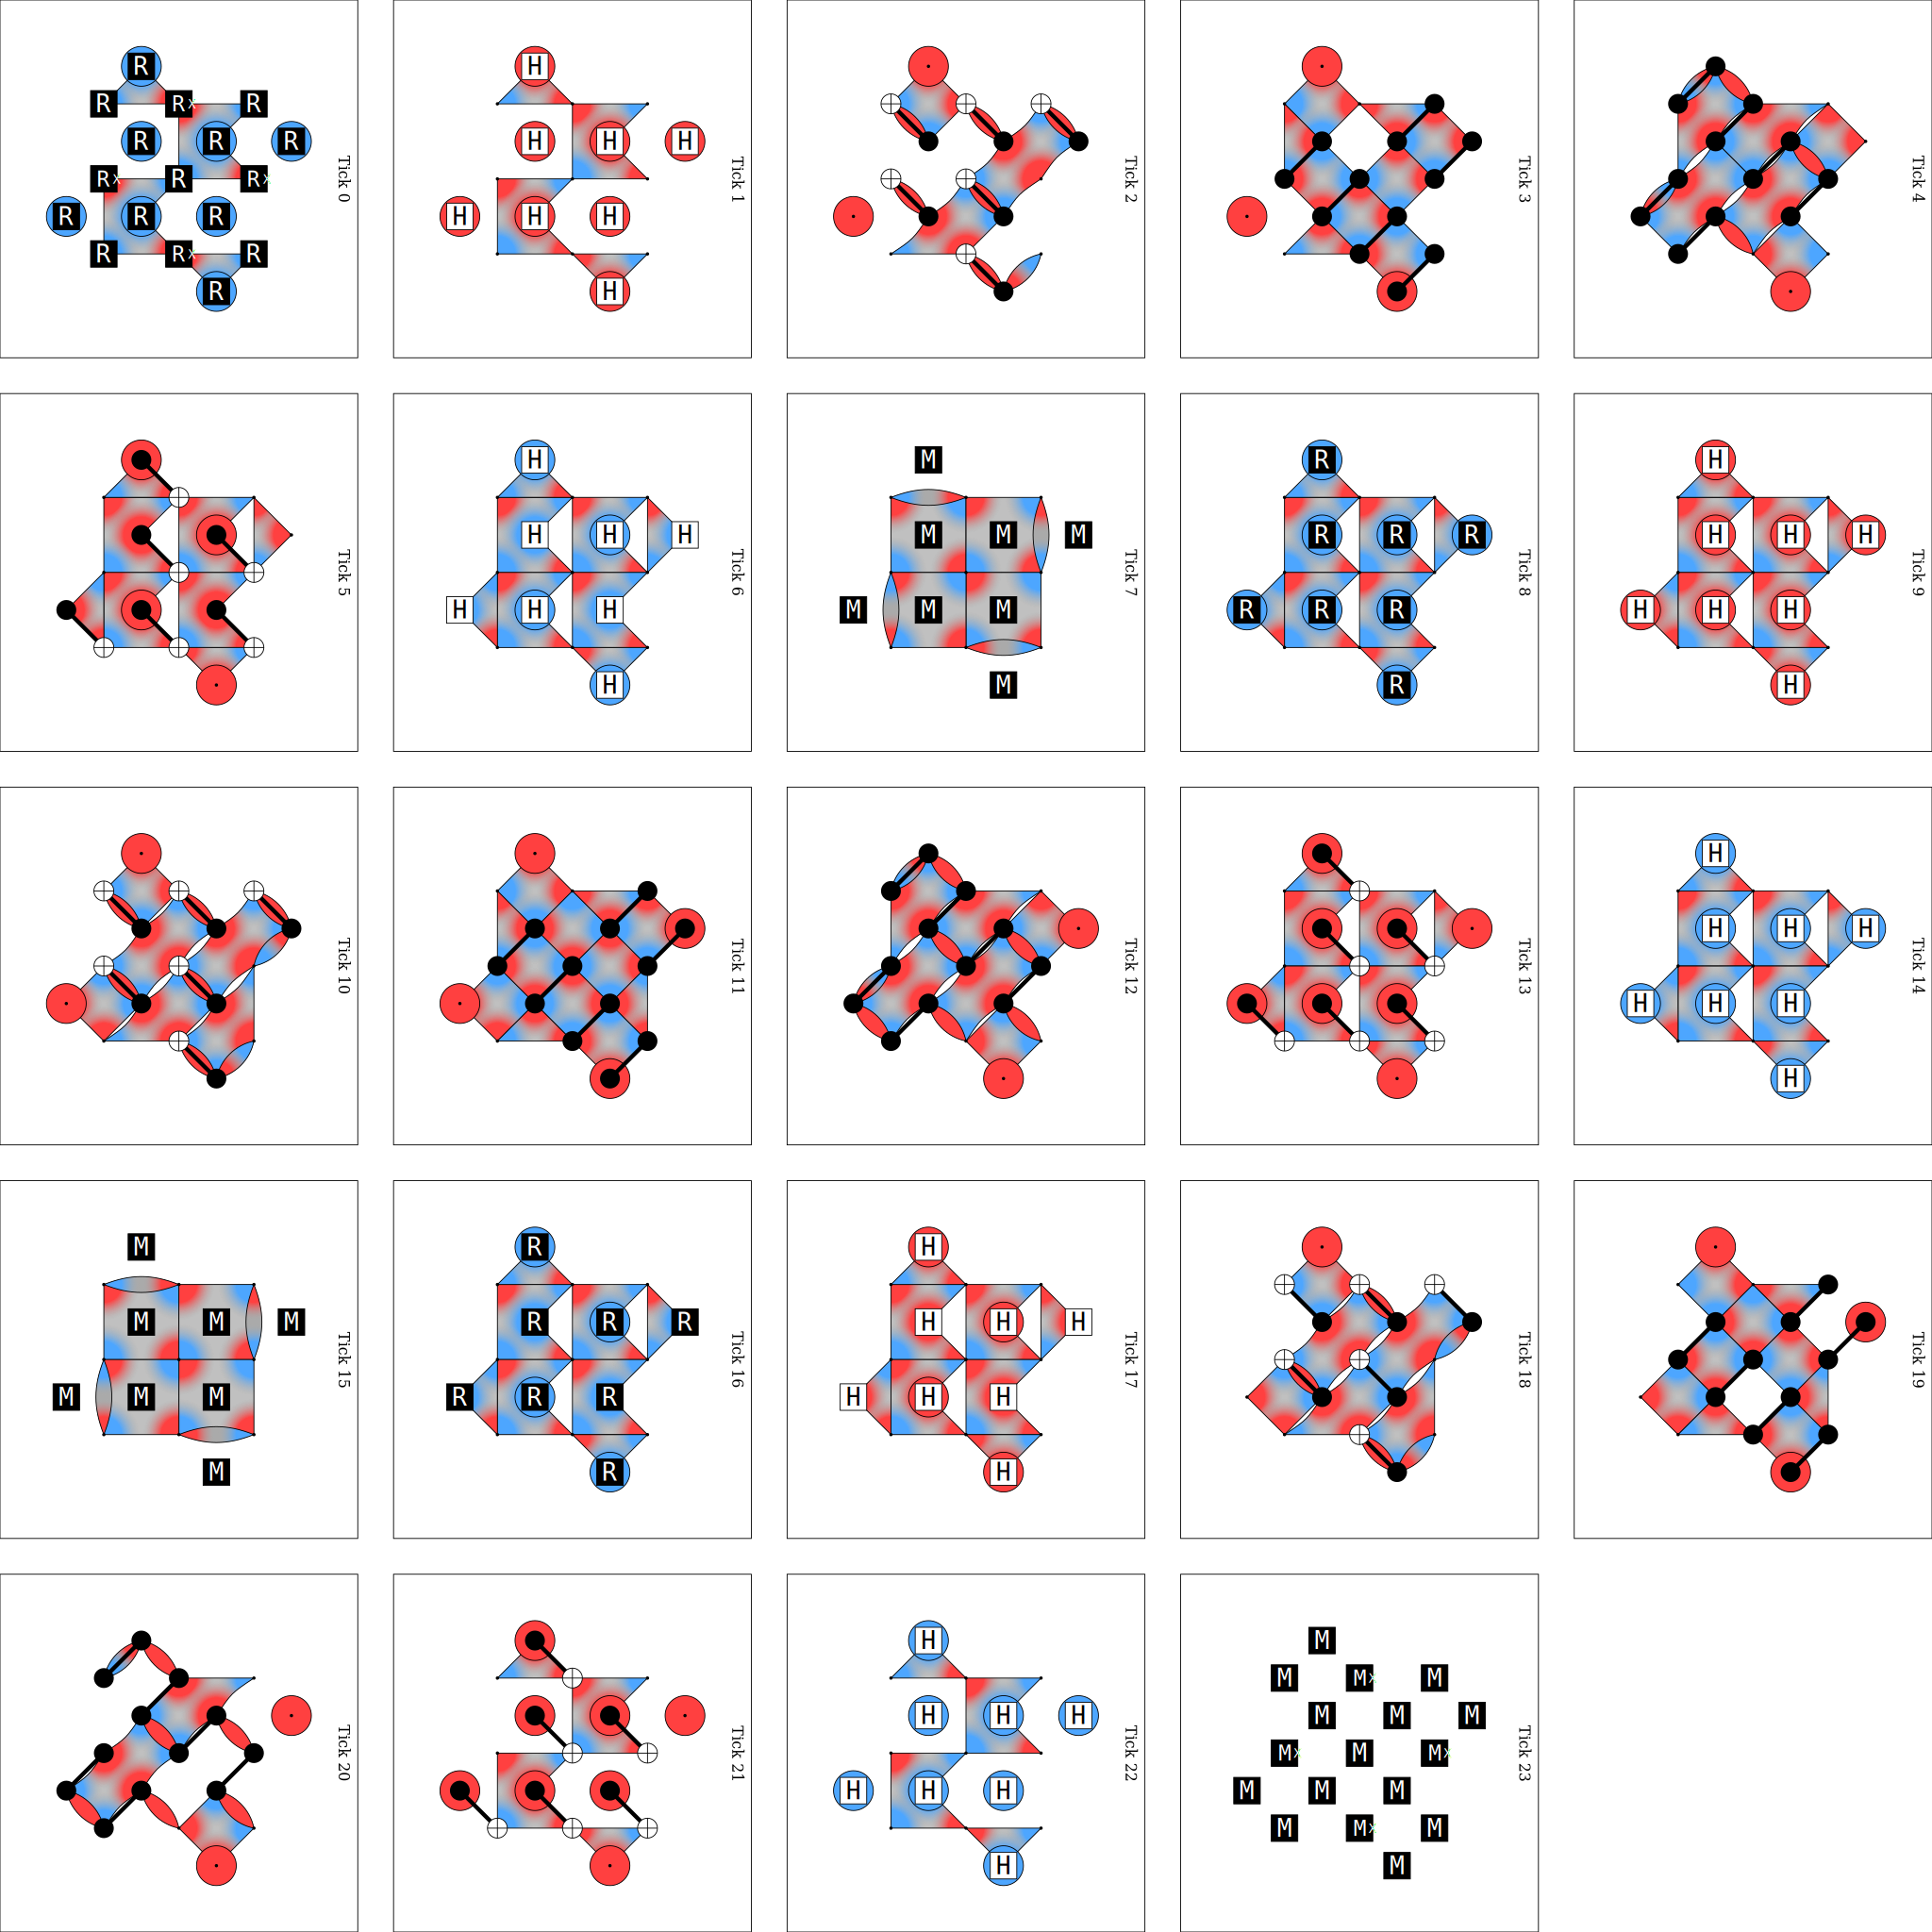

In [5]:
# Detector slice visualization (comment out if notebook becomes slow)
circuit_xzzx.without_noise().diagram("detslice-with-ops-svg")

## 4. Logical error rate vs physical error rate

Circuit-level noise, decoded with pymatching. The d=5 curve falling below d=3 at low p shows
the checkerboard memory exercises the full code distance.

In [6]:
import pymatching

def xzzx_memory_circuit(d, p, basis="Z"):
    system = QECSystem()
    system.add_patch(XZZXSurfaceCode(distance=d), name="xzzx_sc")
    exp = MemoryExperiment(
        qec_system=system,
        extraction_block_class=XZZXSurfaceCodeExtractionBlock,
        rounds=d,
        noise_params=NoiseConfig(p_idle=p, p_1q=p, p_2q=p, p_meas=p, p_reset=p),
        noise_model="circuit_level",
        basis=basis,
        data_basis_map=xzzx_memory_basis(system, basis),
    )
    return exp.build()

def logical_error_rate(circuit, shots=20_000, seed=0):
    dem = circuit.detector_error_model(decompose_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(dem)
    dets, obs = circuit.compile_detector_sampler(seed=seed).sample(
        shots, separate_observables=True)
    pred = matcher.decode_batch(dets)
    errors = np.any(pred != obs, axis=1).sum()
    return max(errors, 0.5) / shots  # 0.5/shots floor so log plots keep zero-error points

ps = [1e-3, 2e-3, 5e-3, 1e-2]
results = {}
for dd in (3, 5):
    results[dd] = [logical_error_rate(xzzx_memory_circuit(dd, pp)) for pp in ps]
    print(f"d={dd}: " + "  ".join(f"{r:.2e}" for r in results[dd]))

d=3: 9.50e-04  3.40e-03  1.77e-02  6.70e-02


d=5: 2.00e-04  1.20e-03  1.57e-02  9.30e-02


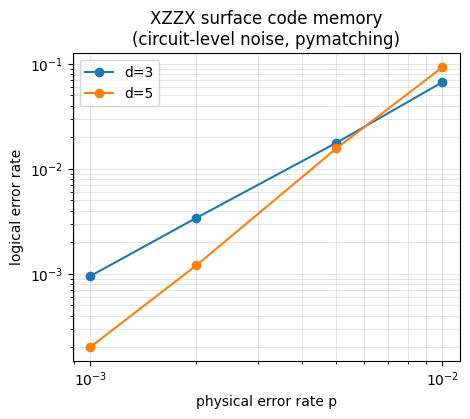

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
for dd, lers in results.items():
    ax.loglog(ps, lers, "o-", label=f"d={dd}")
ax.set_xlabel("physical error rate p")
ax.set_ylabel("logical error rate")
ax.set_title("XZZX surface code memory\n(circuit-level noise, pymatching)")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()